## Image Classification - Brain Tumor Detection using CNN Model

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import cv2
from pathlib import Path

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Checking Tensorflow Version

In [12]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


## Data Loading and Data Preprocessing

In [28]:
def load_images_from_folder(data_path, img_size=(224, 224)):
    images = []
    labels = []
    
    # Get actual folder names (case-insensitive)
    available_folders = os.listdir(data_path)
    
    # Find the correct folder names (case-insensitive matching)
    healthy_folder = None
    tumor_folder = None
    
    for folder in available_folders:
        if folder.lower() == 'healthy':
            healthy_folder = folder
        elif folder.lower() == 'tumor':
            tumor_folder = folder
    
    if not healthy_folder or not tumor_folder:
        raise ValueError(f"Could not find 'healthy' and 'tumor' folders in {data_path}. "
                        f"Available folders: {available_folders}")
    
    # Define class labels with actual folder names
    classes = [healthy_folder, tumor_folder]
    class_mapping = {healthy_folder: 0, tumor_folder: 1}
    
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        
        if not os.path.exists(class_path):
            print(f"Warning: Folder {class_path} does not exist!")
            continue
            
        # Load all images from the class folder
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            try:
                # Read image
                img = cv2.imread(img_path)
                
                if img is None:
                    continue
                
                # Convert BGR to RGB (OpenCV loads as BGR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Resize image to target size
                img = cv2.resize(img, img_size)
                
                # Normalize pixel values to [0, 1]`
                img = img / 255.0
                
                images.append(img)
                labels.append(class_mapping[class_name])
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    
    # Convert to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    if len(images) > 0:
        print(f"Loaded {len(images)} images")
        print(f"Image shape: {images[0].shape}")
        print(f"Class distribution: Healthy={np.sum(labels==0)}, Tumor={np.sum(labels==1)}")
    else:
        print("no images loaded.")
    
    return images, labels

## Train/Test/Split

In [14]:
def preprocess_data(images, labels, test_size=0.2, val_size=0.1):
    """
    Split data into train, validation, and test sets
    """
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        images, labels, test_size=test_size, random_state=42, stratify=labels
    )
    
    # Second split: separate validation set from training
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp
    )
    
    print(f"\nData split:")
    print(f"Training set: {len(X_train)} images")
    print(f"Validation set: {len(X_val)} images")
    print(f"Test set: {len(X_test)} images")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

## Building convolutional layers

In [15]:
def build_cnn_model(input_shape=(224, 224, 3), num_classes=1):
    """
    Build a CNN model for binary classification (tumor vs healthy)
    Architecture includes:
    - Multiple convolutional blocks with batch normalization
    - Max pooling for downsampling
    - Dropout for regularization
    - Dense layers for classification
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer (sigmoid for binary classification)
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model

## Model Training and Data Augmentation

In [16]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32):
    """
    Train the CNN model with data augmentation and callbacks
    """
    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    # Data augmentation for training set
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='nearest'
    )
    
    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    # Train the model
    print("\nStarting model training...")
    history = model.fit(
        train_datagen.flow(X_train, y_train, batch_size=batch_size),
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    return model, history

## Model Evaluation

In [17]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate the trained model on test set
    """
    print("\n" + "="*60)
    print("MODEL EVALUATION ON TEST SET")
    print("="*60)
    
    # Get predictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy: {accuracy:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Tumor']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'Tumor'],
                yticklabels=['Healthy', 'Tumor'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return y_pred, y_pred_prob

## Visualizing Model Validation Metrics

In [18]:
def plot_training_history(history):
    """
    Plot training and validation accuracy/loss curves
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

## Visualizing Model Prediction Metrics on Test Data

In [19]:
def visualize_predictions(X_test, y_test, y_pred, y_pred_prob, num_samples=10):
    """
    Visualize sample predictions
    """
    # Randomly select samples
    indices = np.random.choice(len(X_test), min(num_samples, len(X_test)), replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()
    
    for i, idx in enumerate(indices):
        axes[i].imshow(X_test[idx])
        
        true_label = 'Tumor' if y_test[idx] == 1 else 'Healthy'
        pred_label = 'Tumor' if y_pred[idx] == 1 else 'Healthy'
        confidence = y_pred_prob[idx][0] if y_pred[idx] == 1 else 1 - y_pred_prob[idx][0]
        
        color = 'green' if y_test[idx] == y_pred[idx] else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()


## Main function

BRAIN TUMOR DETECTION - CNN MODEL

[1] Loading images from folder...
Loaded 5000 images
Image shape: (224, 224, 3)
Class distribution: Healthy=2000, Tumor=3000

[2] Preprocessing and splitting data...

Data split:
Training set: 3500 images
Validation set: 500 images
Test set: 1000 images

[3] Building CNN model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,969 (49.36 MB)

 Trainable params: 12,939,265 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

None

[4] Training model...

Starting model training...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7377 - loss: 0.6017 - precision_1: 0.7731 - recall_1: 0.7967 - val_accuracy: 0.4000 - val_loss: 18.6891 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8111 - loss: 0.4397 - precision_1: 0.8299 - recall_1: 0.8619 - val_accuracy: 0.4000 - val_loss: 17.8544 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8371 - loss: 0.3828 - precision_1: 0.8535 - recall_1: 0.8795 - val_accuracy: 0.4000 - val_loss: 14.5558 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8634 - loss: 0.3266 - precision_1: 0.8783 - recall_1: 0.8967 - val_accuracy: 0.4100 - val_loss: 2.2406 - val_precision_1: 0.7778 - val_recall_1: 0.0233 - learning_rate: 0.0010
E

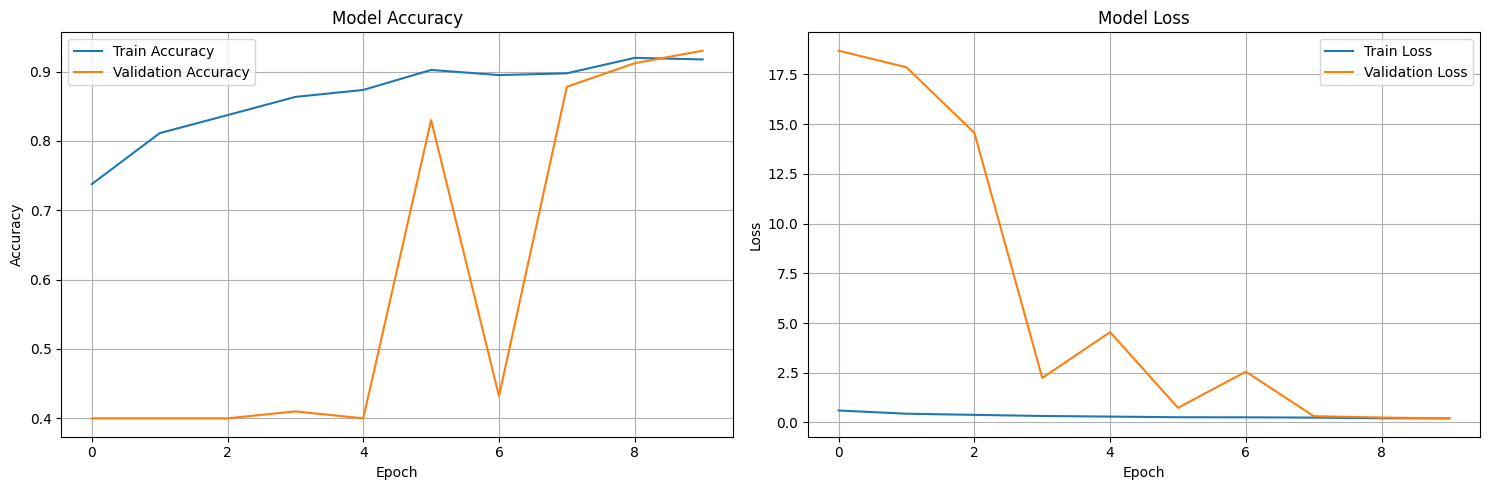


[6] Evaluating model...

MODEL EVALUATION ON TEST SET
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step

Test Accuracy: 0.9440

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.92      0.93       400
       Tumor       0.95      0.96      0.95       600

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



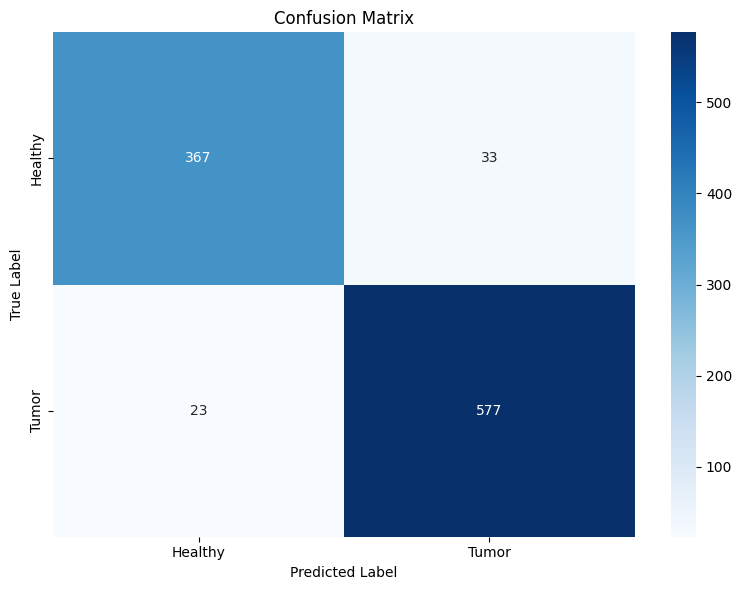


[7] Visualizing sample predictions...


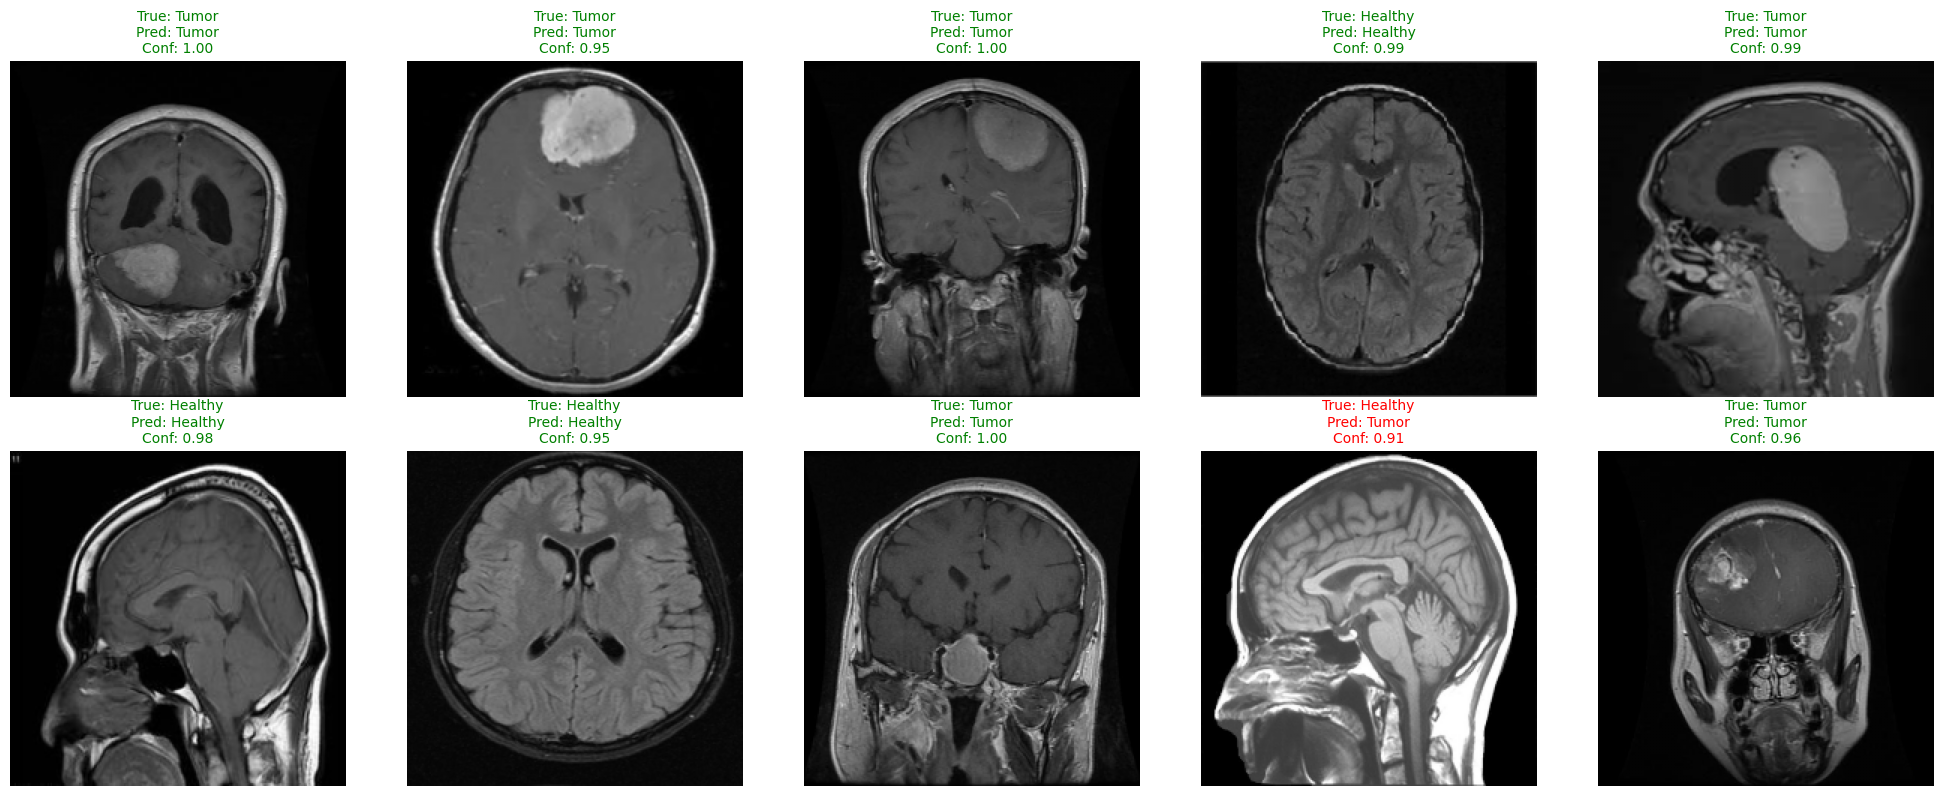


[8] Saving model...
Model saved as 'brain_tumor_cnn_model.h5'

PROCESS COMPLETED SUCCESSFULLY!


In [20]:
if __name__ == "__main__":
    
    # Define data path (update this to your local folder path)
    DATA_PATH = "/Users/sathish/Desktop/Priya Project/BDML/brain_tumor_detection/Dataset/MRI_Images"  # Change this to your data folder
    
    # Image parameters
    IMG_SIZE = (224, 224)
    
    print("="*60)
    print("BRAIN TUMOR DETECTION - CNN MODEL")
    print("="*60)
    
    # Step 1: Load and preprocess data
    print("\n[1] Loading images from folder...")
    images, labels = load_images_from_folder(DATA_PATH, img_size=IMG_SIZE)
    
    print("\n[2] Preprocessing and splitting data...")
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(images, labels)
    
    # Step 2: Build CNN model
    print("\n[3] Building CNN model...")
    model = build_cnn_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    print(model.summary())
    
    # Step 3: Train the model
    print("\n[4] Training model...")
    model, history = train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32)
    
    # Step 4: Plot training history
    print("\n[5] Plotting training history...")
    plot_training_history(history)
    
    # Step 5: Evaluate model on test set
    print("\n[6] Evaluating model...")
    y_pred, y_pred_prob = evaluate_model(model, X_test, y_test)
    
    # Step 6: Visualize predictions
    print("\n[7] Visualizing sample predictions...")
    visualize_predictions(X_test, y_test, y_pred, y_pred_prob, num_samples=10)
    
    # Step 7: Save the model
    print("\n[8] Saving model...")
    model.save('brain_tumor_cnn_model.h5')
    print("Model saved as 'brain_tumor_cnn_model.h5'")
    
    print("\n" + "="*60)
    print("PROCESS COMPLETED SUCCESSFULLY!")
    print("="*60)